In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt


files = {
    #"n1": "/home/mengelsl/MA-bench-framework/outputs/spmv/v2/bla1/results.csv",
    #"n2": "/home/mengelsl/MA-bench-framework/outputs/spmv/v2/bla2/results.csv",
    #"n3": "/home/mengelsl/MA-bench-framework/outputs/spmv/v2/bla3/results.csv",
    #"n4": "/home/mengelsl/MA-bench-framework/outputs/spmv/v2/bla4/results.csv",
    #"n5": "/home/mengelsl/MA-bench-framework/outputs/spmv/v2/bla5/results.csv",
    #"host1": "/home/mengelsl/MA-bench-framework/outputs/spmv/v2/host1/results.csv",
    #"host2": "/home/mengelsl/MA-bench-framework/outputs/spmv/v2/host2/results.csv",
    #"host3": "/home/mengelsl/MA-bench-framework/outputs/spmv/v2/host3/results.csv",
    #"host4": "/home/mengelsl/MA-bench-framework/outputs/spmv/v2/host4/results.csv",
    #"host5": "/home/mengelsl/MA-bench-framework/outputs/spmv/v2/host5/results.csv",
    #"big1": "/home/mengelsl/MA-bench-framework/outputs/spmv/v2/big1/results.csv",
    #"big2": "/home/mengelsl/MA-bench-framework/outputs/spmv/v2/big2/results.csv",
    #"small1": "/home/mengelsl/MA-bench-framework/outputs/spmv/v2/small1/results.csv",
    #"small2": "/home/mengelsl/MA-bench-framework/outputs/spmv/v2/small2/results.csv",
    #"n1": "/home/mengelsl/MA-bench-framework/outputs/spmv/v2/base1/results.csv",
    #"n2": "/home/mengelsl/MA-bench-framework/outputs/spmv/v2/base2/results.csv",
    #"n3": "/home/mengelsl/MA-bench-framework/outputs/spmv/v2/base3/results.csv",
    #"n4": "/home/mengelsl/MA-bench-framework/outputs/spmv/v2/base4/results.csv",
    #"n5": "/home/mengelsl/MA-bench-framework/outputs/spmv/v2/base6/results.csv",
    #"n6": "/home/mengelsl/MA-bench-framework/outputs/spmv/v2/base7/results.csv",
    "z1": "/home/mengelsl/MA-bench-framework/outputs/spmv/v2/z1/results.csv",
    "z2": "/home/mengelsl/MA-bench-framework/outputs/spmv/v2/z2/results.csv",
    "z3": "/home/mengelsl/MA-bench-framework/outputs/spmv/v2/z3/results.csv",
    "z4": "/home/mengelsl/MA-bench-framework/outputs/spmv/v2/z4/results.csv",
    "z5": "/home/mengelsl/MA-bench-framework/outputs/spmv/v2/z5/results.csv",
}
iter = {
    "n1": "/home/mengelsl/MA-bench-framework/outputs/spmv/v2/base1/iter.csv",
    "n2": "/home/mengelsl/MA-bench-framework/outputs/spmv/v2/base2/iter.csv",
}
#CSV format:
all_data = []
for name, path in files.items():
    df = pd.read_csv(path)
    df['Environment'] = name 
    all_data.append(df)
df = pd.concat(all_data, ignore_index=True)

all_data = []
for name, path in iter.items():
    df_iter = pd.read_csv(path)
    df_iter['Environment'] = name 
    all_data.append(df_iter)
df_iter = pd.concat(all_data, ignore_index=True)


SyntaxError: invalid syntax (2192212609.py, line 32)

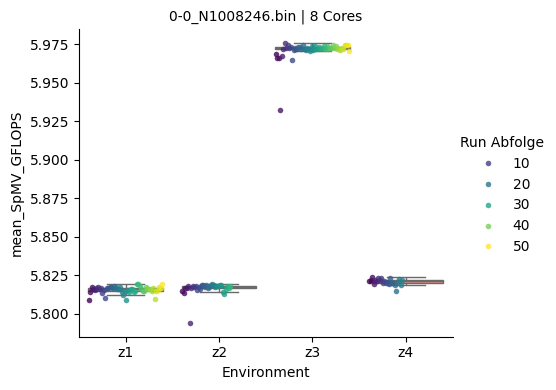

In [17]:
run_means_detailed = (
    df
    .groupby(['Matrix', 'Cores', 'Environment', 'Run'])['SpMV_GFLOPS']
    .mean()
    .reset_index(name='mean_SpMV_GFLOPS')
    .sort_values('Run')
)

g = sns.catplot(
    data=run_means_detailed, 
    x='Environment', 
    y='mean_SpMV_GFLOPS', 
    col='Cores', 
    row='Matrix', 
    kind='box',         
    showfliers=False,
    hue='Environment',          
    palette='Set3',
    height=4, 
    aspect=1.2,
    sharey=False,
    legend=False            
)

# 3. Den Swarmplot drüberlegen mit sequentieller Palette für 'Run'
# 'viridis' geht von Violett (Anfang) über Blau/Grün nach Gelb (Ende)
g.map_dataframe(
    sns.swarmplot, 
    x='Environment', 
    y='mean_SpMV_GFLOPS', 
    hue='Run', 
    palette='viridis', # Sequentielle Palette zeigt die Abfolge
    dodge=True,        # Trennt die Runs leicht auf, falls sie sich überlagern
    size=4,            # Punktgröße etwas kleiner für bessere Übersicht
    alpha=0.8          # Leicht transparent, damit man Überlagerungen sieht
)

# 4. Legende für die Runs hinzufügen (da catplot die Legende für map_dataframe oft nicht automatisch baut)
g.add_legend(title="Run Abfolge", adjust_subtitles=True)

# Optional: Titel der Facetten schöner machen
g.set_titles("{row_name} | {col_name} Cores")

plt.show()

<Axes: xlabel='Perf_dTLBMisses', ylabel='Environment'>

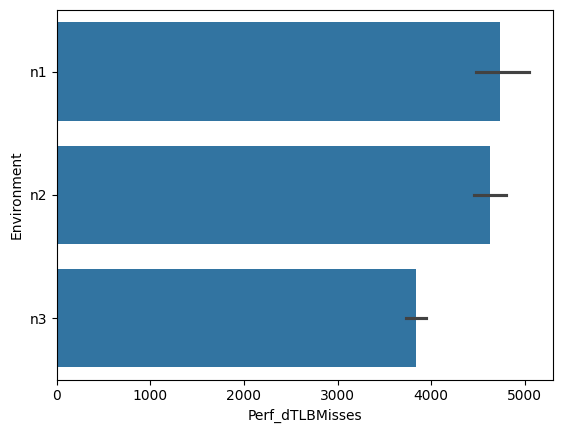

In [133]:
sns.barplot(data=df, x= 'Perf_dTLBMisses', y='Environment')